In [2]:
#!/usr/bin/env python
# coding: utf-8

# In[23]:


import argparse
import json
from pathlib import Path
import math,random,os,sys, importlib, time,copy
import pickle, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, kstest, cramervonmises, chi2, ks_2samp
from scipy import stats

import torch
from torch.utils.data import DataLoader
from joblib import Parallel, delayed
# Repo paths
PWD = Path.cwd().resolve()
ROOT = PWD.parents[0]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Local modules
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)
import train.training_clean as train_training; importlib.reload(train_training)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, compute_mu_safety_map
from data.datasets import SpringDataset, make_sequence_pairs
from data.plotting import plot_x_safety_map, plot_mu_safety_map
from train.models import build_cond_gru_model, EncoderOnly

from train.training_clean import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
    eval_stability_classification,
    eval_regime_batch_stats
)
from train.eval import encode_to_latent

from train.losses import mmd2_unif, energy_distance_unif
from train.training_clean import (
    DivergenceConfig,
    StabilityConfig,
    RegimeConfig,
    TrainingConfig,
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
)
import hypo_test.stats_tests as test_mod; importlib.reload(test_mod)
from hypo_test.stats_tests import uniformity_pvalues_all,ecdf,ks_2sample_pvalue


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Run model diagnostics for the physics-informed hypothesis test."
    )
    parser.add_argument("--seed", type=int, default=1)
    parser.add_argument("--n-samples", type=int, default=8000, dest="n_samples")
    parser.add_argument("--T", type=float, default=10.0)
    parser.add_argument("--dt", type=float, default=0.05)
    parser.add_argument("--stride", type=int, default=1)
    parser.add_argument("--loss_type", type=str, default='stability_asymmetric_recon', dest="loss_type")# {"bce", "weighted", "weighted_bce", "stability_asymmetric_recon"}
    parser.add_argument(
        "--dist-mean",
        type=float,
        nargs=2,
        default=[0.0, 0.0],
        metavar=("MU_X", "MU_Y"),
        dest="dist_mean",
    )
    parser.add_argument(
        "--dist-cov-diag",
        type=float,
        nargs=2,
        default=[1.0, 1.0],
        metavar=("VAR_X", "VAR_Y"),
        dest="dist_cov_diag",
    )
    parser.add_argument("--batch-train", type=int, default=1024, dest="batch_train")
    parser.add_argument("--batch-val", type=int, default=512, dest="batch_val")
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=3e-3)
    parser.add_argument("--weight-decay", type=float, default=1e-5, dest="weight_decay")
    parser.add_argument("--lr-enc", type=float, default=3e-3, dest="lr_enc")
    parser.add_argument(
        "--weight-decay-enc",
        type=float,
        default=0.0,
        dest="weight_decay_enc",
    )
    parser.add_argument("--lambda-mmd", type=float, default=1e-2, dest="lambda_mmd")
    parser.add_argument("--d-x", type=int, default=2, dest="d_x")
    parser.add_argument("--d-o", type=int, default=1, dest="d_o")
    parser.add_argument("--d-v", type=int, default=1, dest="d_v")
    parser.add_argument("--d-h", type=int, default=128, dest="d_h")
    parser.add_argument("--hidden-enc", type=int, default=512, dest="hidden_enc")
    parser.add_argument("--hidden-dec", type=int, default=128, dest="hidden_dec")
    parser.add_argument("--B-bins", type=int, default=20, dest="B_bins")
    parser.add_argument("--tau", type=float, default=1.0)
    parser.add_argument("--asym-recon-delta", type=float, default=10.0, dest="asym_recon_delta")
    parser.add_argument(
        "--time-window",
        type=float,
        nargs=2,
        default=[6.0, 10.0],
        metavar=("T_START", "T_END"),
        dest="time_window",
    )
    parser.add_argument(
        "--lambda-stability",
        type=float,
        default=0.0,
        dest="lambda_stability",
    )
    parser.add_argument("--lambda-regime", type=float, default=0.0, dest="lambda_regime")
    parser.add_argument(
        "--output-dir",
        type=str,
        default=None,
        dest="output_dir",
    )

    args = parser.parse_args(args)

    def _fmt_float(x: float) -> str:
        return f"{x:g}".replace(".", "p")

    if args.output_dir is None:
        args.output_dir = (
            "results/diagnostics_results/"
            f"seed_{args.seed}"
            f"_lr_{_fmt_float(args.lr)}"
            f"_lambda_mmd_{_fmt_float(args.lambda_mmd)}"
            f"_loss_type_{args.loss_type}"
            # f"_epochs_{args.epochs}"
            # f"_n_{args.n_samples}"
        )
        
    args.dist_mean = np.array(args.dist_mean, dtype=float)
    args.dist_cov = np.diag(np.array(args.dist_cov_diag, dtype=float))
    args.time_window = tuple(float(v) for v in args.time_window)
    return args


Cfg = parse_args([])

print("[Config]")
print(f"  seed              : {Cfg.seed}")
print(f"  loss_type         : {Cfg.loss_type}")
print(f"  lr                : {Cfg.lr:g}")
print(f"  lr_enc            : {Cfg.lr_enc:g}")
print(f"  lambda_mmd        : {Cfg.lambda_mmd:g}")
print(f"  lambda_stability  : {Cfg.lambda_stability:g}")
print(f"  lambda_regime     : {Cfg.lambda_regime:g}")
print(f"  asym_recon_delta  : {Cfg.asym_recon_delta:g}")
print(f"  seed              : {Cfg.seed}")
print(f"  epochs            : {Cfg.epochs}")
print(f"  n_samples         : {Cfg.n_samples}")
print(f"  output_dir        : {Cfg.output_dir}")


# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)


[Config]
  seed              : 1
  loss_type         : stability_asymmetric_recon
  lr                : 0.003
  lr_enc            : 0.003
  lambda_mmd        : 0.01
  lambda_stability  : 0
  lambda_regime     : 0
  asym_recon_delta  : 10
  seed              : 1
  epochs            : 100
  n_samples         : 8000
  output_dir        : results/diagnostics_results/seed_1_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon
device: cuda


In [ ]:


z_0 = np.array([0.0, 0.0]) # baselien config
params = SpringParams(mass=1.0, damping=1.0, stiffness=2.0) # paramters theta

X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
)

traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type="sin", config=z_0)
s = traj["s"]                           # (N, T_full)
assert X.shape[0] == s.shape[0]


y = check_safety(
    traj=traj,
    threshold=Cfg.tau,
    window=Cfg.time_window,
).astype(np.float32)


o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

print("Shapes -> X:", x_np.shape, "trajectory shape:", s.shape)

N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx], y=y[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx], y=y[va_idx])

loader_kwargs = {
    "num_workers": max(int(Cfg.num_workers), 0),
    "pin_memory": device.type == "cuda",
}
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(
    train_ds,
    batch_size=Cfg.batch_train,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_ds,
    batch_size=Cfg.batch_val,
    shuffle=False,
    **loader_kwargs,
)

Shapes -> X: (8000, 2) trajectory shape: (8000, 201)


In [30]:
import copy

# Divergence configuration
from train.losses import mmd2_unif, energy_distance_unif

div_fn = mmd2_unif
# Stable, low-variance settings; override as needed.
div_kwargs = {"sigmas": None, "low_discrepancy": True}

model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1
).to(device)

# Encoder-only variant for pure latent uniform divergence regularization.
model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)

Cfg.epochs = 100
history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss, val_rec, val_div = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
    )

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_recon": val_rec,
        "val_divergence": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        msg = f"[{epoch:02d}] train-loss={tr_loss:.6f}"
        if use_val:
            msg += (f"  val-recon={val_rec:.6f}  val-divergence={val_div:.6f}  "
                    f"  train-divergence (enc)={tr_div_enc:.6f} val-divergence (enc)={val_div_enc:.6f}")
        print(msg)

if use_val and best_state is not None:
    model.load_state_dict(best_state)
pd.DataFrame(history).tail()


[01] train-loss=0.123578  val-recon=0.088226  val-divergence=0.031049    train-divergence (enc)=0.209534 val-divergence (enc)=0.029704
[10] train-loss=0.003330  val-recon=0.002999  val-divergence=0.028704    train-divergence (enc)=0.001181 val-divergence (enc)=0.003321
[20] train-loss=0.000304  val-recon=0.000217  val-divergence=0.000339    train-divergence (enc)=0.000662 val-divergence (enc)=-0.000513
[30] train-loss=0.000074  val-recon=0.000075  val-divergence=0.000288    train-divergence (enc)=0.002429 val-divergence (enc)=-0.000539
[40] train-loss=0.000050  val-recon=0.000049  val-divergence=-0.000229    train-divergence (enc)=-0.000053 val-divergence (enc)=0.000191
[50] train-loss=0.000035  val-recon=0.000038  val-divergence=-0.000095    train-divergence (enc)=0.001141 val-divergence (enc)=-0.000391
[60] train-loss=0.000028  val-recon=0.000032  val-divergence=-0.000299    train-divergence (enc)=-0.000348 val-divergence (enc)=-0.000304
[70] train-loss=0.000027  val-recon=0.000032  

,epoch,train_loss,val_recon,val_divergence,train_div (enc-only),val_divergence (enc-only)
95,96,0.000027,0.000040,-0.000208,0.000365,-0.000406
96,97,0.000043,0.000047,-0.000052,0.000198,-0.000453
97,98,0.000033,0.000029,-0.000358,0.000413,-0.000151
98,99,0.000031,0.000047,-0.000501,-0.000141,0.000114
99,100,0.000032,0.000028,-0.000507,0.000196,0.000481


In [ ]:
import copy

# Divergence configuration
from train.losses import mmd2_unif, energy_distance_unif

Cfg.epochs = 100
# Cfg.lr = 5e-4
# Cfg.lambda_mmd = 0.05
Cfg.lambda_stability = 0
Cfg.lambda_regime = 0
Cfg.regime_gamma= 0.9
Cfg.regime_delta_safe= 0.01
Cfg.regime_delta_unsafe= 0.1
    

div_fn = mmd2_unif # or energy_distance_unif or Wasserstein distance (# TO BE IMPLEMENTED)
# Stable, low-variance settings; override as needed.
div_kwargs = {"sigmas": None, "low_discrepancy": True}

model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1
).to(device)

# Encoder-only variant for pure latent uniform divergence regularization.
model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)


history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):

    tr_loss, val_rec, val_div, val_stability = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
        return_val_stability=True,
        stability_spec={
            "lambda": Cfg.lambda_stability,
            "fn": check_safety,
            "fn_kwargs": {
                "threshold": Cfg.tau,
                "window": Cfg.time_window,   # (t_l, t_u), absolute times
            },
            "dt": Cfg.dt * Cfg.stride,
            "t0": Cfg.dt * Cfg.stride,       # because o_next starts at first predicted step
            "safe_weight": 1.0,      # y=1
            "unsafe_weight": 9.0,    # y=0 (about inverse freq for 90/10)
        },
        lambda_regime=Cfg.lambda_regime,
        regime_gamma=Cfg.regime_gamma,
        regime_delta_safe=Cfg.regime_delta_safe,
        regime_delta_unsafe=Cfg.regime_delta_unsafe,
        stability_weight_stab = 1,
        stability_loss_type ='bce'
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        lambda_mmd=Cfg.lambda_mmd,
        device=device,
        val_loader=val_loader if use_val else None,
        divergence_fn=div_fn,
        divergence_kwargs=div_kwargs,
    )
    reg = None
    if use_val and Cfg.lambda_regime > 0:
        reg = eval_regime_batch_stats(
            loader=val_loader,   # or train_loader if you prefer train-side stats
            model=model,
            device=device,
            divergence_fn=div_fn,
            divergence_kwargs=div_kwargs,
            regime_gamma=Cfg.regime_gamma,
            regime_delta_safe=Cfg.regime_delta_safe,
            regime_delta_unsafe=Cfg.regime_delta_unsafe,
        )


    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_recon": val_rec,
        "val_stability": val_stability,
        "val_divergence": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
        "reg_safe_batches": None if reg is None else reg["safe_batches"],
        "reg_unsafe_batches": None if reg is None else reg["unsafe_batches"],
        "reg_frac_safe_batches": None if reg is None else reg["frac_safe_batches"],
        "reg_frac_unsafe_batches": None if reg is None else reg["frac_unsafe_batches"],
        "reg_safe_q50": None if reg is None else reg["safe_div_q50"],
        "reg_safe_q90": None if reg is None else reg["safe_div_q90"],
        "reg_unsafe_q50": None if reg is None else reg["unsafe_div_q50"],
        "reg_unsafe_q90": None if reg is None else reg["unsafe_div_q90"],
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    # if epoch % 10 == 0 or epoch == 1:
    #     msg = f"[{epoch:02d}] train-loss={tr_loss:.6f}"
    #     if use_val:
    #         msg += f"  val-recon={val_rec:.6f}  val-divergence={val_div:.6f}"
    #         if val_stability is not None:
    #             msg += f"  val-stability={val_stability:.6f}"
    #         msg += (f"  train-divergence (enc)={tr_div_enc:.6f}"
    #                 f"  val-divergence (enc)={val_div_enc:.6f}")
    #     print(msg)
    def _fmt(x):
        return "NA" if x is None else f"{x:.3f}"

    if epoch % 10 == 0 or epoch == 1:
        msg = f"[{epoch:02d}] train-loss={tr_loss:.6f}"
        if use_val:
            msg += f"  val-recon={val_rec:.6f}  val-divergence={val_div:.6f}"
            if val_stability is not None:
                msg += f"  val-stability={val_stability:.6f}"

            # classification stats on val set
            cls = eval_stability_classification(
                loader=val_loader,
                model=model,
                device=device,
                stability_spec={
                    "fn": check_safety,
                    "fn_kwargs": {"threshold": Cfg.tau, "window": Cfg.time_window},
                    "dt": Cfg.dt * Cfg.stride,
                    "t0": Cfg.dt * Cfg.stride,
                    "smooth_beta": 10.0,
                },
            )
            msg += (
                f"  y1-frac={_fmt(cls['frac_y1'])}"
                f"  y0-frac={_fmt(cls['frac_y0'])}"
                f"  y1-correct={_fmt(cls['y1_correct_frac'])}"
                f"  y0-correct={_fmt(cls['y0_correct_frac'])}"
                f"  cls-err={_fmt(1.0 - cls['overall_acc'])}"
                f"  cls-acc={_fmt(cls['overall_acc'])}"
            )

            if Cfg.lambda_regime > 0 and reg is not None:
                msg += (
                    f"  regime-safe-batches={reg['safe_batches']}/{reg['num_batches']}"
                    f" ({reg['frac_safe_batches']:.3f})"
                    f"  regime-unsafe-batches={reg['unsafe_batches']}/{reg['num_batches']}"
                    f" ({reg['frac_unsafe_batches']:.3f})"
                    f"  safe-div[q50,q90]=[{_fmt(reg['safe_div_q50'])},{_fmt(reg['safe_div_q90'])}]"
                    f"  unsafe-div[q50,q90]=[{_fmt(reg['unsafe_div_q50'])},{_fmt(reg['unsafe_div_q90'])}]"
                    f"  regime-hinge={reg['avg_regime_hinge_loss']:.6f}"
                )

            msg += (f"  train-divergence (enc)={tr_div_enc:.6f}"
                    f"  val-divergence (enc)={val_div_enc:.6f}")
        print(msg)


if use_val and best_state is not None:
    model.load_state_dict(best_state)
pd.DataFrame(history).tail()


ValueError: not enough values to unpack (expected 4, got 3)

In [31]:
@torch.no_grad()
def encode_to_latent(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []
    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start+batch_size]
        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)
        vs.append(vb.detach().cpu())
    return torch.cat(vs, dim=0).numpy()

def stats_for_latents(v, B=Cfg.B_bins):
    v = np.asarray(v)
    ks_p   = stats.kstest(v[:, 0], "uniform", args=(0, 1)).pvalue  # d_v=1 here
    cvm_p  = stats.cramervonmises(v[:, 0], "uniform", args=(0, 1)).pvalue
    _, chi2_p, _ = chisq_uniform_1d(v[:, 0], b=B)
    return ks_p, cvm_p, chi2_p


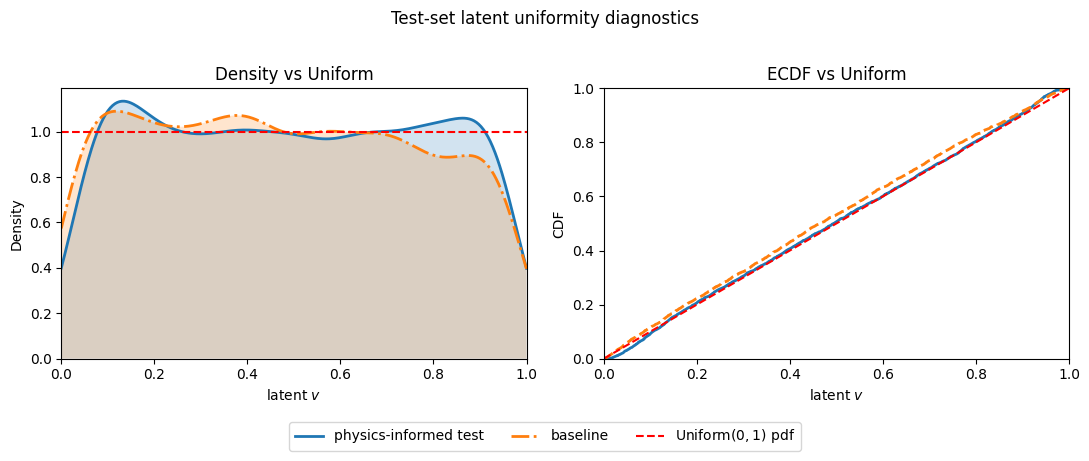

[Uniformity p-values vs Unif(0,1)]
  proposed: KS_p=0.0401
  proposed: CvM_p=0.165
  proposed: MMD_p=1
  proposed: ED_p=1
  proposed: Chi2=0.0932
  baseline: KS_p=1.63e-05
  baseline: CvM_p=5.71e-07
  baseline: MMD_p=1
  baseline: ED_p=1
  baseline: Chi2=0.0932


In [32]:

def pvals_ks_cvm_to_uniform(v_np: np.ndarray):
    v = np.asarray(v_np, float).ravel()
    v = np.clip(v, 0.0, 1.0)  # if your latent is intended in [0,1]
    p_ks  = float(kstest(v, "uniform", args=(0.0, 1.0)).pvalue)
    p_cvm = float(cramervonmises(v, "uniform").pvalue)
    return p_ks, p_cvm

@torch.no_grad()
def mmd_stat(v_np, device, ref_u):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    return float(mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item())

@torch.no_grad()
def energy_stat(v_np, device, ref_u):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    # use your CPU version (or your MPS-safe version if you have it)
    return float(energy_distance_unif(v.cpu(), ref_u.cpu()).item())

@torch.no_grad()
def perm_pvalue_two_sample(stat_fn, x, y, *, B=300, device="cpu", seed=0):
    """
    Two-sample permutation test p-value for statistic stat_fn(x,y),
    where stat_fn uses a fixed reference y (uniform) passed in.

    Returns p = (1 + #{T_perm >= T_obs})/(B+1).
    """
    rng = np.random.default_rng(seed)

    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    n = x.shape[0]
    assert y.shape[0] == n, "Use equal sample sizes for clean permutation test."

    # torch refs
    y_t = torch.as_tensor(y, device=device, dtype=torch.float32).view(-1, 1)
    T_obs = stat_fn(x, device, ref_u=y_t)

    z = np.concatenate([x, y], axis=0)
    ge = 0
    for b in range(B):
        perm = rng.permutation(2 * n)
        x_b = z[perm[:n]]
        y_b = z[perm[n:]]
        y_b_t = torch.as_tensor(y_b, device=device, dtype=torch.float32).view(-1, 1)
        T_b = stat_fn(x_b, device, ref_u=y_b_t)
        ge += int(T_b >= T_obs)

    p = (ge + 1.0) / (B + 1.0)
    return float(T_obs), float(p)


def chi2_pvalue_to_uniform(v_np, B=20):
    v = np.asarray(v_np, float).ravel()
    v = np.clip(v, 0.0, 1.0)

    edges = np.linspace(0.0, 1.0, B + 1)
    counts, _ = np.histogram(v, bins=edges)

    expected = v.size / B
    if expected < 5:
        raise ValueError(f"Expected count n/B={expected:.2f} < 5; reduce B or increase n.")

    x2 = np.sum((counts - expected) ** 2 / expected)
    p = 1.0 - chi2.cdf(x2, df=B - 1)
    return float(x2), float(p)



X_splits = {
    "X_train": x_np[tr_idx],
    "X_val":   x_np[va_idx],
    "X_test":  sample_x(
        n_samples=2000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=1,
    ).astype(np.float32),
}


# -----------------------
# 1) compute latents once
# -----------------------
v_np  = encode_to_latent(model,     X_splits["X_train"], device)[:, 0]
v0_np = encode_to_latent(model_enc, X_splits["X_train"], device)[:, 0]

# clip for uniformity checks/plots if needed
# v_np  = np.clip(v_np,  0.0, 1.0)
# v0_np = np.clip(v0_np, 0.0, 1.0)

# -----------------------
# 2) make 2-panel plot
# -----------------------
grid = np.linspace(0, 1, 400)
kde_v  = gaussian_kde(v_np)(grid)
kde_v0 = gaussian_kde(v0_np)(grid)

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = ecdf(v_np)
x2, y2 = ecdf(v0_np)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# (a) KDE vs Uniform pdf
ax = axes[0]
ax.plot(grid, kde_v,  linewidth=2, label="physics-informed test")
ax.fill_between(grid, 0, kde_v, alpha=0.20)
ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline")
ax.fill_between(grid, 0, kde_v0, alpha=0.20)
ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("Density")
ax.set_title("Density vs Uniform")

# (b) ECDF vs Uniform CDF
ax = axes[1]
ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("CDF")
ax.set_title("ECDF vs Uniform")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
fig.legend(handles , labels , loc="lower center", ncol=3, frameon=True,bbox_to_anchor=(0.5, -0.1),)
# plt.legend()

fig.suptitle("Test-set latent uniformity diagnostics", y=1.02)
fig.tight_layout()
plt.show()

# -----------------------
# 3) print metrics
# -----------------------
# KS distance to Uniform(0,1): sup |F_n(t) - t|
def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))

v  = torch.as_tensor(v_np,  device=device, dtype=torch.float32).view(-1, 1)
v0 = torch.as_tensor(v0_np, device=device, dtype=torch.float32).view(-1, 1)

def uniformity_pvalues_all(v_np, v0_np, *, device, B=300, seed=0):
    v_np  = np.clip(np.asarray(v_np,  float).ravel(), 0.0, 1.0)
    v0_np = np.clip(np.asarray(v0_np, float).ravel(), 0.0, 1.0)

    n = v_np.shape[0]
    rng = np.random.default_rng(seed)
    u = rng.random(n)  # Uniform(0,1) reference, fixed for all tests

    # KS / CvM
    ks_p,  cvm_p  = pvals_ks_cvm_to_uniform(v_np)
    ks_p0, cvm_p0 = pvals_ks_cvm_to_uniform(v0_np)

    # MMD / Energy (permutation)
    mmd_stat_v,  mmd_p  = perm_pvalue_two_sample(mmd_stat,    v_np,  u, B=B, device=device, seed=seed+1)
    mmd_stat_v0, mmd_p0 = perm_pvalue_two_sample(mmd_stat,    v0_np, u, B=B, device=device, seed=seed+2)

    ed_stat_v,   ed_p   = perm_pvalue_two_sample(energy_stat, v_np,  u, B=B, device=device, seed=seed+3)
    ed_stat_v0,  ed_p0  = perm_pvalue_two_sample(energy_stat, v0_np, u, B=B, device=device, seed=seed+4)
    _,chi2_p = chi2_pvalue_to_uniform(v_np,B=10)
    _,chi2_p0 = chi2_pvalue_to_uniform(v_np,B=10)
    return {
        "proposed": {"KS_p": ks_p,  "CvM_p": cvm_p,  "MMD_stat": mmd_stat_v,  "MMD_p": mmd_p,  "ED_stat": ed_stat_v,  "ED_p": ed_p,'Chi2':chi2_p},
        "baseline": {"KS_p": ks_p0, "CvM_p": cvm_p0, "MMD_stat": mmd_stat_v0, "MMD_p": mmd_p0, "ED_stat": ed_stat_v0, "ED_p": ed_p0,'Chi2':chi2_p0},
        "n": int(n),
        "B": int(B),
    }


pvals = uniformity_pvalues_all(v_np, v0_np, device=device, B=0, seed=0)

print("[Uniformity p-values vs Unif(0,1)]")
for name in ["proposed", "baseline"]:
    d = pvals[name]
    for key, value in d.items():
        if 'stat' in key:
            continue
        print(f"  {name}: {key}={value:.3g}")
    

# with torch.no_grad():
#     # shared reference uniforms for variance reduction
#     ref_u = torch.rand_like(v)

#     # shared sigma grid for fair comparison (use your median heuristic once)
#     mmd_v  = mmd2_unif(v,  sigmas=None, ref_u=ref_u, use_median=False).item()
#     mmd_v0 = mmd2_unif(v0, sigmas=None, ref_u=ref_u, use_median=False).item()

#     # if you are on MPS, use the MPS-safe energy version (cdist-based) you defined earlier
#     # ed_v  = energy_distance_unif_mps(v,  ref_u=ref_u).item()
#     # ed_v0 = energy_distance_unif_mps(v0, ref_u=ref_u).item()

#     # or CPU fallback (slower, but works)
#     ed_v  = energy_distance_unif(v.cpu(),  ref_u.cpu()).item()
#     ed_v0 = energy_distance_unif(v0.cpu(), ref_u.cpu()).item()

# ks_v  = ks_to_uniform(v_np)
# ks_v0 = ks_to_uniform(v0_np)

# print("[Uniformity metrics on X_test]  (unbiased estimators may be slightly negative)")
# print(f"  MMD^2(proposed, Unif): {mmd_v:+.6e}")
# print(f"  MMD^2(baseline,  Unif): {mmd_v0:+.6e}")
# print(f"  Energy(proposed, Unif): {ed_v:+.6e}")
# print(f"  Energy(baseline,  Unif): {ed_v0:+.6e}")
# print(f"  KS(proposed vs Unif):   {ks_v:.6e}")
# print(f"  KS(baseline vs Unif):   {ks_v0:.6e}")


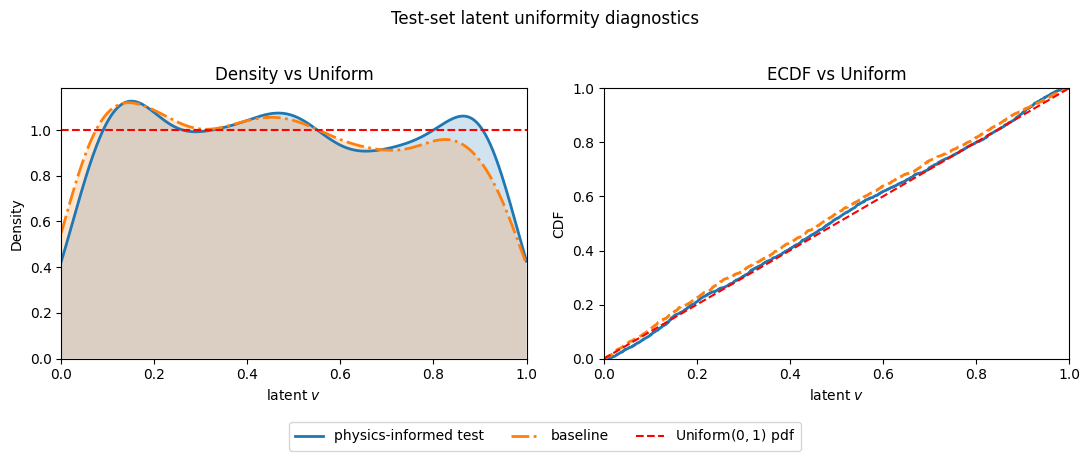

[Uniformity metrics on X_test]  (unbiased estimators may be slightly negative)
  MMD^2(proposed, Unif): +1.072884e-05
  MMD^2(baseline,  Unif): +8.604527e-04
  Energy(proposed, Unif): +1.257658e-05
  Energy(baseline,  Unif): +1.152247e-03
  KS(proposed vs Unif):   2.424767e-02
  KS(baseline vs Unif):   4.019620e-02


In [33]:

X_splits = {
    "X_train": x_np[tr_idx],
    "X_val":   x_np[va_idx],
    "X_test":  sample_x(
        n_samples=2000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=1,
    ).astype(np.float32),
}


# -----------------------
# 1) compute latents once
# -----------------------
v_np  = encode_to_latent(model,     X_splits["X_test"], device)[:, 0]
v0_np = encode_to_latent(model_enc, X_splits["X_test"], device)[:, 0]

# clip for uniformity checks/plots if needed
# v_np  = np.clip(v_np,  0.0, 1.0)
# v0_np = np.clip(v0_np, 0.0, 1.0)

# -----------------------
# 2) make 2-panel plot
# -----------------------
grid = np.linspace(0, 1, 400)
kde_v  = gaussian_kde(v_np)(grid)
kde_v0 = gaussian_kde(v0_np)(grid)

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x1, y1 = ecdf(v_np)
x2, y2 = ecdf(v0_np)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# (a) KDE vs Uniform pdf
ax = axes[0]
ax.plot(grid, kde_v,  linewidth=2, label="physics-informed test")
ax.fill_between(grid, 0, kde_v, alpha=0.20)
ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline")
ax.fill_between(grid, 0, kde_v0, alpha=0.20)
ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("Density")
ax.set_title("Density vs Uniform")

# (b) ECDF vs Uniform CDF
ax = axes[1]
ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"latent $v$")
ax.set_ylabel("CDF")
ax.set_title("ECDF vs Uniform")

# one shared legend
handles, labels = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()
fig.legend(handles , labels , loc="lower center", ncol=3, frameon=True,bbox_to_anchor=(0.5, -0.1),)
# plt.legend()

fig.suptitle("Test-set latent uniformity diagnostics", y=1.02)
fig.tight_layout()
plt.show()

# -----------------------
# 3) print metrics
# -----------------------
# KS distance to Uniform(0,1): sup |F_n(t) - t|
def ks_to_uniform(x):
    x = np.sort(x)
    n = len(x)
    Fn = np.arange(1, n + 1) / n
    return float(np.max(np.abs(Fn - x)))

v  = torch.as_tensor(v_np,  device=device, dtype=torch.float32).view(-1, 1)
v0 = torch.as_tensor(v0_np, device=device, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    # shared reference uniforms for variance reduction
    ref_u = torch.rand_like(v)

    # shared sigma grid for fair comparison (use your median heuristic once)
    mmd_v  = mmd2_unif(v,  sigmas=None, ref_u=ref_u, use_median=False).item()
    mmd_v0 = mmd2_unif(v0, sigmas=None, ref_u=ref_u, use_median=False).item()

    # if you are on MPS, use the MPS-safe energy version (cdist-based) you defined earlier
    # ed_v  = energy_distance_unif_mps(v,  ref_u=ref_u).item()
    # ed_v0 = energy_distance_unif_mps(v0, ref_u=ref_u).item()

    # or CPU fallback (slower, but works)
    ed_v  = energy_distance_unif(v.cpu(),  ref_u.cpu()).item()
    ed_v0 = energy_distance_unif(v0.cpu(), ref_u.cpu()).item()

ks_v  = ks_to_uniform(v_np)
ks_v0 = ks_to_uniform(v0_np)

print("[Uniformity metrics on X_test]  (unbiased estimators may be slightly negative)")
print(f"  MMD^2(proposed, Unif): {mmd_v:+.6e}")
print(f"  MMD^2(baseline,  Unif): {mmd_v0:+.6e}")
print(f"  Energy(proposed, Unif): {ed_v:+.6e}")
print(f"  Energy(baseline,  Unif): {ed_v0:+.6e}")
print(f"  KS(proposed vs Unif):   {ks_v:.6e}")
print(f"  KS(baseline vs Unif):   {ks_v0:.6e}")


## Data Shift: Mean Perturbation

Let $\mathbb{P}_0 = \mathcal{N}(\mu, \Sigma)$, where
$
\mu=\begin{bmatrix}0\\0\end{bmatrix},
\Sigma=\begin{bmatrix}1 & 0\\ 0 & 1\end{bmatrix}.
$
In mean perturbation case, we consider $\mathbb{P}_1 = \mathcal{N}(\mu', \Sigma)$, with $\mu'=\begin{bmatrix}0\\0\end{bmatrix},$


In [34]:
# for mu in each grid, compute how latent distribtuon diviate from unifrom, say under the null and under the alternative, 
# loop over mu:
#   for each mu, generate Xs: 
#       encode Xs to latent vs (two models)
#       compute vs divergence to uniform distribution
# plot divergence vs mu 

# setting 1 (under null): with mu=(0,0), set mu' = (0,delta), say delta = 0 to 1 with stepsize 0.1
# setting 2 (null to alternative): with mu=(0,0), set mu' = (delta,0), say delta = 0 to 1 with stepsize 0.1, after say delta = 0.5, it cross boundary, config change to unsafe
# setting 3 (under alternative): with mu=(0,0), set mu' = (-1,delta), say delta = 0 to 1 with stepsize 0.1, always alternative



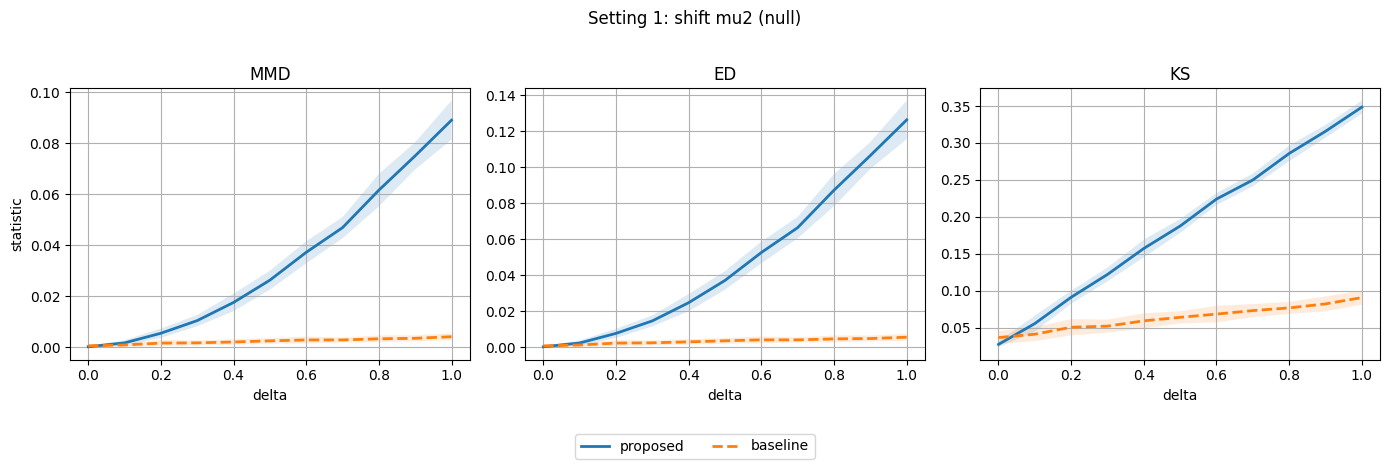

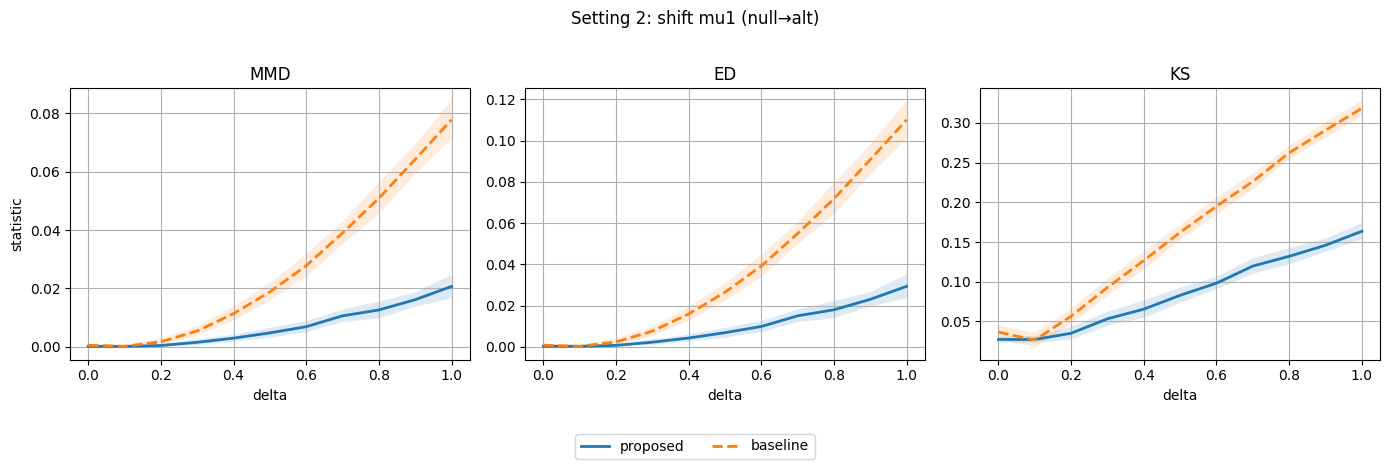

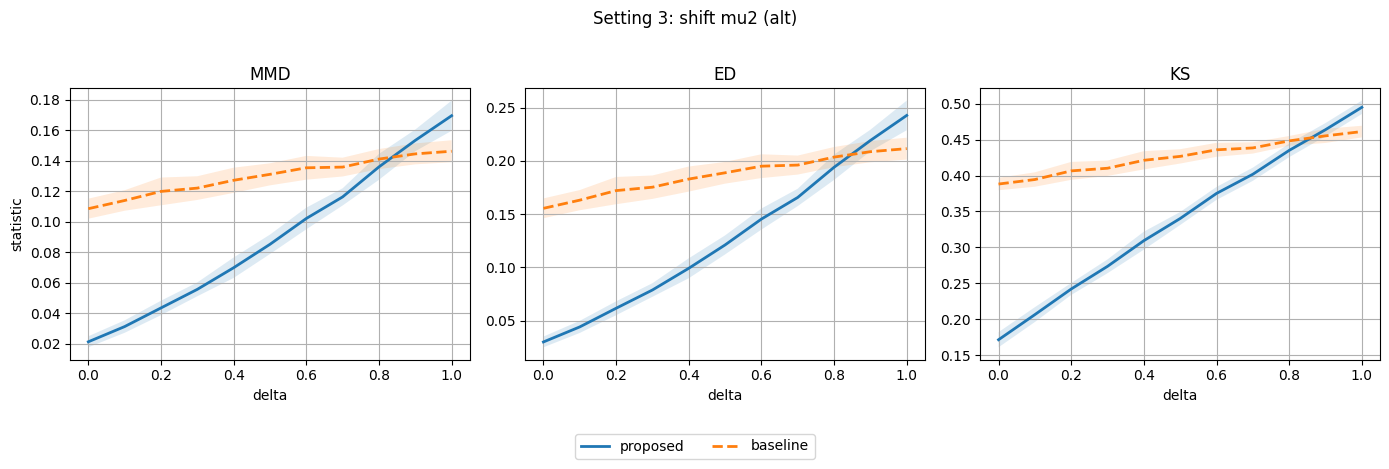

In [35]:
import os
import pathlib
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif, energy_distance_unif


# ---------- runtime guards for WSL + CUDA ----------
def configure_runtime(device):
    torch.set_num_threads(max(1, min(8, (os.cpu_count() or 8) // 2)))
    if torch.device(device).type == "cuda":
        torch.backends.cudnn.benchmark = False  # reduce unpredictable memory spikes


def pick_workers(n_jobs, device, n_tasks):
    if n_jobs in (-1, None):
        want = 2 if torch.device(device).type == "cuda" else max(1, (os.cpu_count() or 4) - 1)
    else:
        want = max(1, int(n_jobs))
    if torch.device(device).type == "cuda":
        want = min(want, 4)  # safe cap for WSL stability
    return min(want, n_tasks)


# ---------- helpers ----------
def ks_to_uniform(x):
    x = np.sort(np.asarray(x, dtype=np.float32).reshape(-1))
    n = x.shape[0]
    Fn = np.arange(1, n + 1, dtype=np.float32) / n
    return float(np.max(np.abs(Fn - x)))


def _to_col_tensor(v, device):
    if torch.is_tensor(v):
        return v.to(device=device, dtype=torch.float32).view(-1, 1)
    return torch.as_tensor(v, device=device, dtype=torch.float32).view(-1, 1)


@torch.inference_mode()
def divergences(v, device, ref_u_gpu=None, ref_u_cpu=None):
    v_gpu = _to_col_tensor(v, device)

    if ref_u_gpu is None:
        ref_u_gpu = torch.rand_like(v_gpu)
    mmd = mmd2_unif(v_gpu, sigmas=None, ref_u=ref_u_gpu, use_median=False).item()

    v_cpu = v_gpu.detach().cpu()
    if ref_u_cpu is None:
        ref_u_cpu = ref_u_gpu.detach().cpu()
    ed = energy_distance_unif(v_cpu, ref_u_cpu).item()
    ks = ks_to_uniform(v_cpu.numpy())
    return mmd, ed, ks


def sweep_direction_parallel(
    mu_base,
    direction,
    deltas,
    *,
    model,
    model_enc,
    device,
    n_samples=2000,
    truncate_box=None,
    seed=1,
    n_reps=10,
    n_jobs=-1,
    max_retries=1,
):
    device = torch.device(device)
    configure_runtime(device)
    model.eval()
    model_enc.eval()

    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=len(deltas) * n_reps, dtype=np.uint32)
    tasks = [(i, float(delta), int(seeds[i * n_reps + j])) for i, delta in enumerate(deltas) for j in range(n_reps)]
    workers = pick_workers(n_jobs, device, len(tasks))

    def one(delta, rep_seed):
        mu = np.asarray(mu_base, dtype=float) + delta * np.asarray(direction, dtype=float)
        X = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu, "cov": np.diag([1.0, 1.0])},
            seed=rep_seed,
            truncate_box=truncate_box,
        ).astype(np.float32)

        g = torch.Generator(device=device).manual_seed(rep_seed)
        ref_u_gpu = torch.rand((n_samples, 1), device=device, generator=g)
        ref_u_cpu = ref_u_gpu.detach().cpu()

        v_prop = encode_to_latent(model, X, device)[:, 0]
        v_base = encode_to_latent(model_enc, X, device)[:, 0]

        mmd_p, ed_p, ks_p = divergences(v_prop, device, ref_u_gpu=ref_u_gpu, ref_u_cpu=ref_u_cpu)
        mmd_b, ed_b, ks_b = divergences(v_base, device, ref_u_gpu=ref_u_gpu, ref_u_cpu=ref_u_cpu)
        return mu[0], mu[1], mmd_p, mmd_b, ed_p, ed_b, ks_p, ks_b

    out = [[] for _ in deltas]
    with ThreadPoolExecutor(max_workers=workers) as ex:
        future_map = {}
        for idx, delta, s in tasks:
            f = ex.submit(one, delta, s)
            future_map[f] = (idx, delta, s, 0)

        while future_map:
            for f in as_completed(list(future_map.keys())):
                idx, delta, s, retry = future_map.pop(f)
                try:
                    out[idx].append(f.result())
                except RuntimeError as e:
                    if "CUDA out of memory" in str(e) and retry < max_retries and device.type == "cuda":
                        torch.cuda.empty_cache()
                        torch.cuda.synchronize()
                        f2 = ex.submit(one, delta, s)
                        future_map[f2] = (idx, delta, s, retry + 1)
                    else:
                        raise

    rows = []
    for i, delta in enumerate(deltas):
        stats = np.asarray(out[i], dtype=np.float64)
        rows.append(
            {
                "delta": float(delta),
                "mu1": float(stats[0, 0]),
                "mu2": float(stats[0, 1]),
                "mmd_prop": float(stats[:, 2].mean()),
                "mmd_base": float(stats[:, 3].mean()),
                "ed_prop": float(stats[:, 4].mean()),
                "ed_base": float(stats[:, 5].mean()),
                "ks_prop": float(stats[:, 6].mean()),
                "ks_base": float(stats[:, 7].mean()),
                "mmd_prop_std": float(stats[:, 2].std()),
                "mmd_base_std": float(stats[:, 3].std()),
                "ed_prop_std": float(stats[:, 4].std()),
                "ed_base_std": float(stats[:, 5].std()),
                "ks_prop_std": float(stats[:, 6].std()),
                "ks_base_std": float(stats[:, 7].std()),
            }
        )
    return pd.DataFrame(rows)


def plot_metrics_row(df, setting_title):
    metrics = ["mmd", "ed", "ks"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(df["delta"], df[f"{metric}_prop"], lw=2, label="proposed")
        ax.plot(df["delta"], df[f"{metric}_base"], lw=2, ls="--", label="baseline")
        ax.fill_between(
            df["delta"],
            df[f"{metric}_prop"] - df[f"{metric}_prop_std"],
            df[f"{metric}_prop"] + df[f"{metric}_prop_std"],
            alpha=0.15,
        )
        ax.fill_between(
            df["delta"],
            df[f"{metric}_base"] - df[f"{metric}_base_std"],
            df[f"{metric}_base"] + df[f"{metric}_base_std"],
            alpha=0.15,
        )
        ax.set_xlabel("delta")
        ax.set_title(metric.upper())
        ax.grid(True)
    axes[0].set_ylabel("statistic")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(setting_title, y=1.02)
    fig.tight_layout()
    plt.show()


# ---------- run ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
deltas = np.linspace(0, 1, 11)
truncate_box = (-3.0, 3.0)
n_reps = 30

# Keep this low on CUDA+WSL (2-4 recommended)
safe_jobs = 3

df1 = sweep_direction_parallel(
    mu_base=(0, 0), direction=(0, 1), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=safe_jobs
)
plot_metrics_row(df1, "Setting 1: shift mu2 (null)")

df2 = sweep_direction_parallel(
    mu_base=(0, 0), direction=(1, 0), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=safe_jobs
)
plot_metrics_row(df2, "Setting 2: shift mu1 (null→alt)")

df3 = sweep_direction_parallel(
    mu_base=(-1, 0), direction=(0, 1), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=safe_jobs
)
plot_metrics_row(df3, "Setting 3: shift mu2 (alt)")


In [ ]:
import os
import math
import pathlib
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif


# Optional: reduce CPU oversubscription (helps WSL stability)
torch.set_num_threads(max(1, min(8, (os.cpu_count() or 8) // 2)))


@torch.inference_mode()
def mmd_only(v_np, device, ref_u=None):
    v = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    if ref_u is None:
        ref_u = torch.rand_like(v)
    return mmd2_unif(v, sigmas=None, ref_u=ref_u, use_median=False).item()


def _resolve_workers(n_jobs, n_tasks, device):
    if n_jobs in (-1, None):
        # Conservative default for CUDA on WSL
        req = 2 if torch.device(device).type == "cuda" else max(1, (os.cpu_count() or 4) - 1)
    else:
        req = int(n_jobs)
    if req < 1:
        req = 1
    # Hard cap for CUDA to avoid context/memory pressure in WSL
    if torch.device(device).type == "cuda":
        req = min(req, 4)
    return min(req, n_tasks)


def sweep_direction_parallel(
    mu_base,
    direction,
    deltas,
    *,
    model,
    model_enc,
    device,
    n_samples=2000,
    truncate_box=None,
    seed=1,
    n_reps=10,
    n_jobs=-1,
    max_retries=1,
):
    device = torch.device(device)
    model.eval()
    model_enc.eval()

    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=len(deltas) * n_reps, dtype=np.uint32)
    tasks = [(i, float(delta), int(seeds[i * n_reps + j])) for i, delta in enumerate(deltas) for j in range(n_reps)]

    workers = _resolve_workers(n_jobs, len(tasks), device)

    def one(delta, rep_seed):
        mu = np.asarray(mu_base, dtype=float) + delta * np.asarray(direction, dtype=float)
        X = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu, "cov": np.diag([1.0, 1.0])},
            seed=rep_seed,
            truncate_box=truncate_box,
        ).astype(np.float32)

        g = torch.Generator(device=device).manual_seed(rep_seed)
        ref_u = torch.rand((n_samples, 1), device=device, generator=g)

        v_p = encode_to_latent(model, X, device)[:, 0]
        v_b = encode_to_latent(model_enc, X, device)[:, 0]

        mmd_p = mmd_only(v_p, device, ref_u=ref_u)
        mmd_b = mmd_only(v_b, device, ref_u=ref_u)
        return delta, mu[0], mu[1], mmd_p, mmd_b

    results = [None] * len(tasks)

    with ThreadPoolExecutor(max_workers=workers) as ex:
        fut_to_idx = {}
        for idx, delta, s in tasks:
            fut = ex.submit(one, delta, s)
            fut_to_idx[fut] = (idx, delta, s, 0)

        while fut_to_idx:
            for fut in as_completed(list(fut_to_idx.keys())):
                idx, delta, s, retry = fut_to_idx.pop(fut)
                try:
                    results_idx = idx * n_reps + (sum(1 for t in tasks if t[0] == idx and t[2] <= s) - 1)
                    results[results_idx] = fut.result()
                except RuntimeError as e:
                    is_cuda_oom = "CUDA out of memory" in str(e)
                    if is_cuda_oom and retry < max_retries:
                        if device.type == "cuda":
                            torch.cuda.empty_cache()
                            torch.cuda.synchronize()
                        fut2 = ex.submit(one, delta, s)
                        fut_to_idx[fut2] = (idx, delta, s, retry + 1)
                    else:
                        raise

    # Re-pack by delta order
    grouped = {float(d): [] for d in deltas}
    for r in results:
        grouped[float(r[0])].append(r)

    rows = []
    for delta in deltas:
        delta = float(delta)
        chunk = grouped[delta]
        mmd_p = [r[3] for r in chunk]
        mmd_b = [r[4] for r in chunk]
        mu1, mu2 = chunk[0][1], chunk[0][2]
        rows.append(
            {
                "delta": delta,
                "mu1": mu1,
                "mu2": mu2,
                "mmd_prop": float(np.mean(mmd_p)),
                "mmd_base": float(np.mean(mmd_b)),
                "mmd_prop_std": float(np.std(mmd_p)),
                "mmd_base_std": float(np.std(mmd_b)),
            }
        )
    return pd.DataFrame(rows)


# ---------- run ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
deltas = np.linspace(0, 1.5, 11)
truncate_box = (-3.0, 3.0)
n_reps = 50

# Keep n_jobs conservative on CUDA+WSL (2-4 usually stable)
df1 = sweep_direction_parallel(
    mu_base=(0, 0), direction=(0, 1), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=3
)
df2 = sweep_direction_parallel(
    mu_base=(0, 0), direction=(1, 0), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=3
)
df3 = sweep_direction_parallel(
    mu_base=(-1, 0), direction=(0, 1), deltas=deltas,
    model=model, model_enc=model_enc, device=device,
    truncate_box=truncate_box, n_reps=n_reps, n_jobs=3
)


In [16]:
payload = {
    "df1": df1,
    "df2": df2,
    "df3": df3,
    "config": dict(
        deltas=deltas,
        truncate_box=truncate_box,
        n_reps=n_reps,
    ),
}

# save
out_path = ROOT / "cache" / "mmd_sweep_deltas_reps.pkl"
out_path.parent.mkdir(parents=True, exist_ok=True)

with out_path.open("wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)


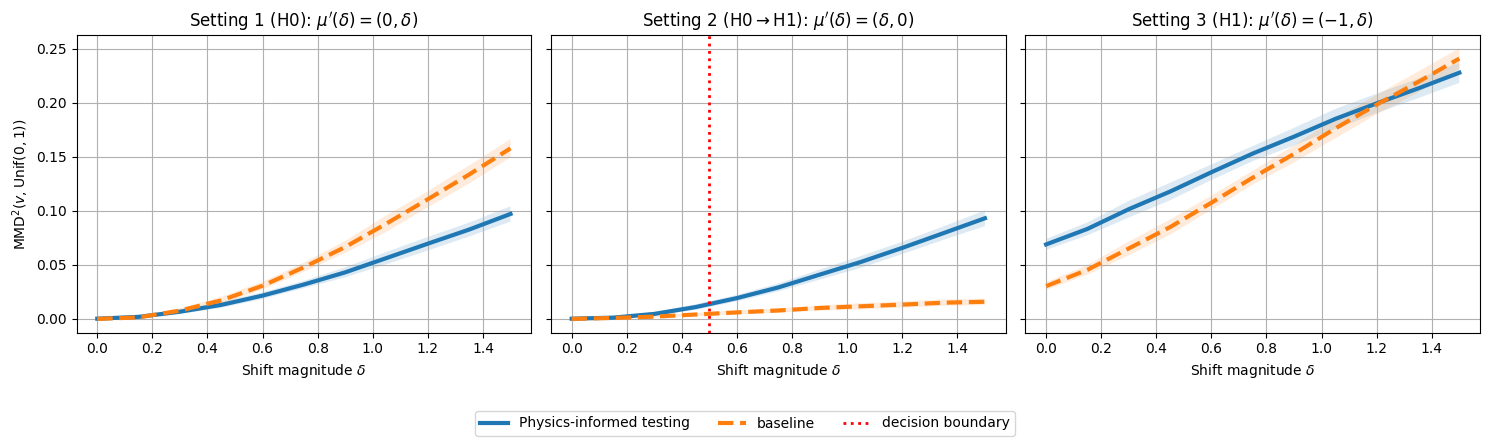

In [17]:
# ---------- helpers ----------
def plot_mmd_three(df1, df2, df3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, df, title in zip(axes, [df1, df2, df3],
                             [r"Setting 1 (H0): $\mu'(\delta)=(0,\delta)$",
                              r"Setting 2 (H0$\to$H1): $\mu'(\delta)=(\delta,0)$",
                              r"Setting 3 (H1): $\mu'(\delta)=(-1,\delta)$",]):
        ax.plot(df["delta"], df["mmd_prop"], lw=3, label=r"Physics-informed testing")
        ax.plot(df["delta"], df["mmd_base"], lw=3, ls="--", label="baseline")
        ax.fill_between(df["delta"],
                        df["mmd_prop"] - df["mmd_prop_std"],
                        df["mmd_prop"] + df["mmd_prop_std"],
                        alpha=0.15)
        ax.fill_between(df["delta"],
                        df["mmd_base"] - df["mmd_base_std"],
                        df["mmd_base"] + df["mmd_base_std"],
                        alpha=0.15)
        if title.startswith("Setting 2"):
            ax.axvline(0.5, color="red", ls=":", lw=2, label="decision boundary")
        ax.set_xlabel(r"Shift magnitude $\delta$"); ax.set_title(title); ax.grid(True)
    axes[0].set_ylabel(r"$\mathrm{MMD}^2(v,\mathrm{Unif}(0,1))$")

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
    # fig.suptitle("MMD Divergence", y=1.02)
    fig.tight_layout()
    plt.show()


plot_mmd_three(df1, df2, df3)

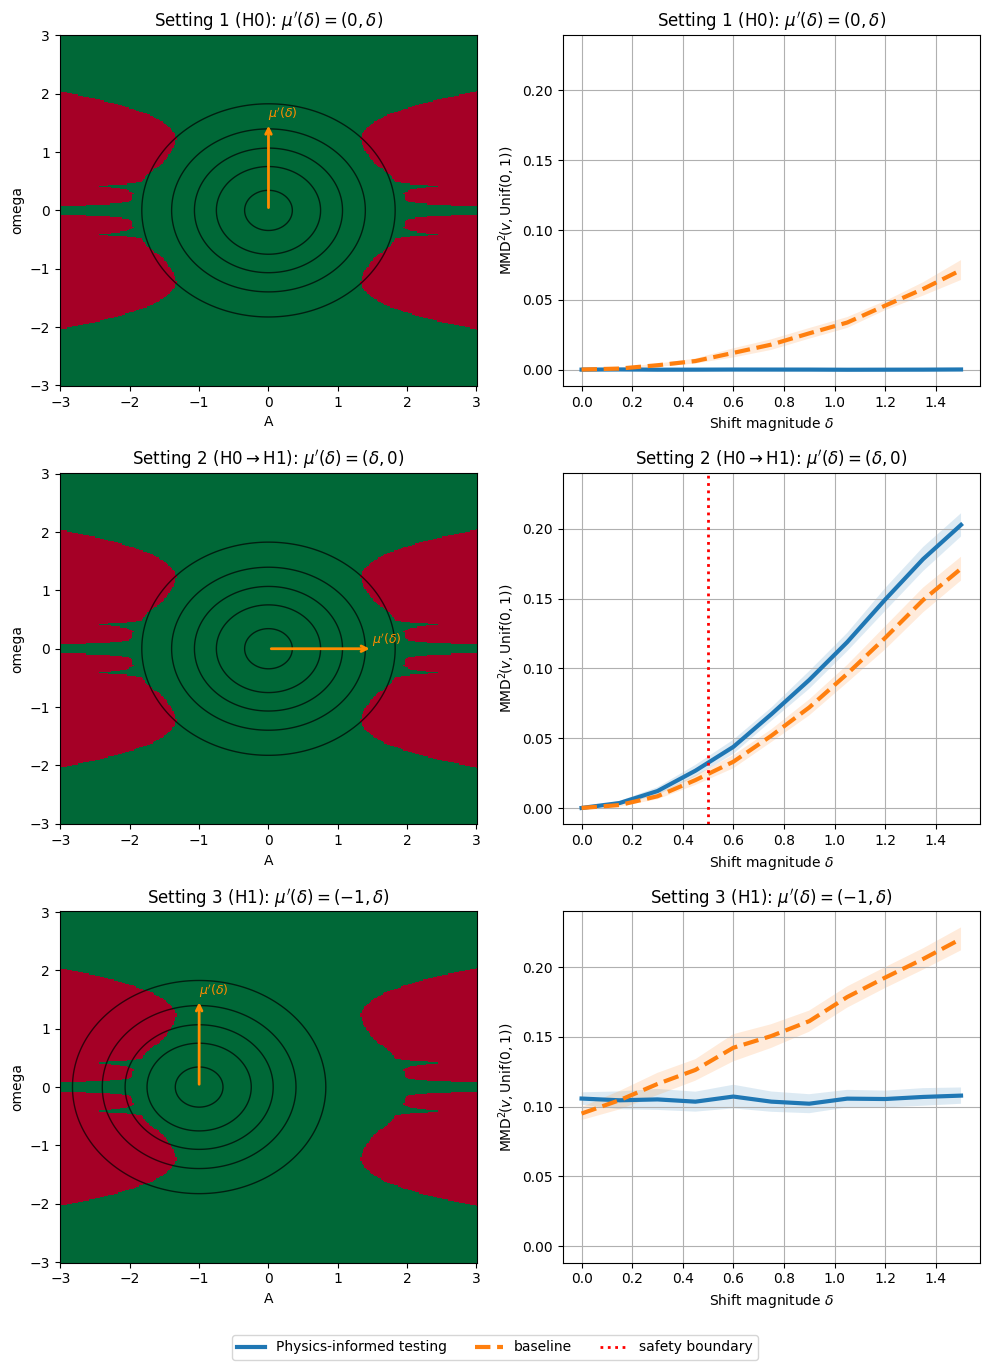

In [55]:


mean_test = np.array([0.0,0])
cov_test = np.diag([1, 1])
x_safety_path = ROOT / "cache" / "res_x_safety.pkl"
with pathlib.Path(x_safety_path).open("rb") as f:
    res_x_safety = pickle.load(f)


# assumes res_x_safety, df1, df2, df3, mean_test, cov_test already loaded
# mean_test = np.array([0.0, 0.0]); cov_test = np.diag([1,1])


def plot_mmd_panel(ax, df, title, decision_boundary ):
    ax.plot(df["delta"], df["mmd_prop"], lw=3, label=r"Physics-informed testing")
    ax.plot(df["delta"], df["mmd_base"], lw=3, ls="--", label="baseline")
    ax.fill_between(df["delta"],
                    df["mmd_prop"] - df["mmd_prop_std"],
                    df["mmd_prop"] + df["mmd_prop_std"], alpha=0.15)
    ax.fill_between(df["delta"],
                    df["mmd_base"] - df["mmd_base_std"],
                    df["mmd_base"] + df["mmd_base_std"], alpha=0.15)
    if "Setting 2" in title:
        ax.axvline(decision_boundary, color="red", ls=":", lw=2, label="safety boundary")
    ax.set_xlabel(r"Shift magnitude $\delta$")
    ax.set_title(title)
    ax.grid(True)

def plot_safety_panel(ax, res, mean, cov, direction, title, contour_levels=5, eta=0.1):
    a_vals = res["A"]; w_vals = res["omega"]; safe = res["safe"]
    A_grid, W_grid = np.meshgrid(a_vals, w_vals, indexing="xy")
    ax.pcolormesh(a_vals, w_vals, safe, cmap="RdYlGn", shading="auto", vmin=0, vmax=1)
    ax.set_xlabel("A"); ax.set_ylabel(r"omega"); ax.set_title(title); ax.grid(False)

    # Gaussian contour
    mu = np.asarray(mean, float).reshape(2)
    sigma = np.asarray(cov, float).reshape(2, 2)
    inv = np.linalg.inv(sigma); det = np.linalg.det(sigma)
    grid = np.stack([A_grid.ravel(), W_grid.ravel()], axis=1)
    diff = grid - mu.reshape(1, 2)
    quad = np.einsum("bi,ij,bj->b", diff, inv, diff)
    Z = np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(det))
    Z = Z.reshape(A_grid.shape)
    ax.contour(A_grid, W_grid, Z, levels=contour_levels, colors="black", linewidths=1.0, alpha=0.7)

    # arrow for direction (starts at provided mean)
    start = np.asarray(mean, float)
    end = start + 1.5 * np.asarray(direction, float)  # scale length visually
    ax.annotate("", xy=end, xycoords="data", xytext=start, textcoords="data",
                arrowprops=dict(arrowstyle="->", lw=2, color="darkorange"))
    ax.text(end[0], end[1], r"$\mu'(\delta)$", color="darkorange", fontsize=9, ha="left", va="bottom")

# Setting definitions: (title, start_mu, direction vector, df)
settings = [
    (r"Setting 1 (H0): $\mu'(\delta)=(0,\delta)$",      np.array([0.0, 0.0]), np.array([0.0, 1.0]), df1),
    (r"Setting 2 (H0$\to$H1): $\mu'(\delta)=(\delta,0)$", np.array([0.0, 0.0]), np.array([1.0, 0.0]), df2),
    (r"Setting 3 (H1): $\mu'(\delta)=(-1,\delta)$",     np.array([-1.0, 0.0]), np.array([0.0, 1.0]), df3),
]

fig, axes = plt.subplots(3, 2, figsize=(10, 14), sharey="col")
plt.subplots_adjust(hspace=0.35)

for row, (title, start_mu, direction, df) in enumerate(settings):
    # left: safety map with arrow (use setting-specific start_mu)
    plot_safety_panel(axes[row, 0], res_x_safety, start_mu, cov_test, direction, title.replace(" (H0$\to$H1)", ""))
    # right: MMD curve
    plot_mmd_panel(axes[row, 1], df, title,decision_boundary=0.5)

for ax in axes[:, 1]:
    ax.set_ylabel(r"$\mathrm{MMD}^2\!\left(v,\mathrm{Unif}(0,1)\right)$")
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()



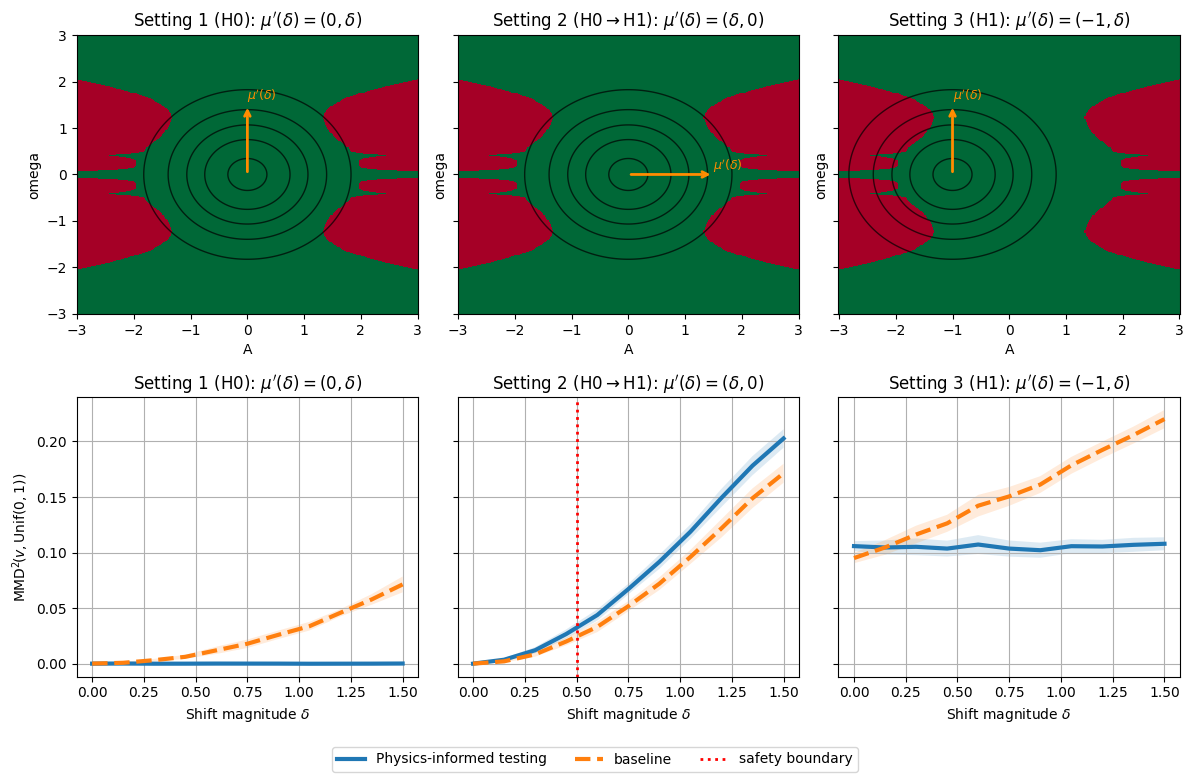

In [57]:

def plot_mmd_panel(ax, df, title, decision_boundary=None):
    ax.plot(df["delta"], df["mmd_prop"], lw=3, label=r"Physics-informed testing")
    ax.plot(df["delta"], df["mmd_base"], lw=3, ls="--", label="baseline")
    ax.fill_between(df["delta"],
                    df["mmd_prop"] - df["mmd_prop_std"],
                    df["mmd_prop"] + df["mmd_prop_std"], alpha=0.15)
    ax.fill_between(df["delta"],
                    df["mmd_base"] - df["mmd_base_std"],
                    df["mmd_base"] + df["mmd_base_std"], alpha=0.15)
    if decision_boundary is not None:
        ax.axvline(decision_boundary, color="red", ls=":", lw=2, label="safety boundary")
    ax.set_xlabel(r"Shift magnitude $\delta$")
    ax.set_title(title)
    ax.grid(True)

def plot_safety_panel(ax, res, mean, cov, direction, title, contour_levels=5):
    a_vals = res["A"]; w_vals = res["omega"]; safe = res["safe"]
    A_grid, W_grid = np.meshgrid(a_vals, w_vals, indexing="xy")
    ax.pcolormesh(a_vals, w_vals, safe, cmap="RdYlGn", shading="auto", vmin=0, vmax=1)
    ax.set_xlabel("A"); ax.set_ylabel(r"omega"); ax.set_title(title); ax.grid(False)

    # Gaussian contour
    mu = np.asarray(mean, float).reshape(2)
    sigma = np.asarray(cov, float).reshape(2, 2)
    inv = np.linalg.inv(sigma); det = np.linalg.det(sigma)
    grid = np.stack([A_grid.ravel(), W_grid.ravel()], axis=1)
    diff = grid - mu.reshape(1, 2)
    quad = np.einsum("bi,ij,bj->b", diff, inv, diff)
    Z = np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(det))
    Z = Z.reshape(A_grid.shape)
    ax.contour(A_grid, W_grid, Z, levels=contour_levels, colors="black", linewidths=1.0, alpha=0.7)

    # arrow for direction (starts at provided mean)
    start = np.asarray(mean, float)
    end = start + 1.5 * np.asarray(direction, float)  # scale arrow length visually
    ax.annotate("", xy=end, xycoords="data", xytext=start, textcoords="data",
                arrowprops=dict(arrowstyle="->", lw=2, color="darkorange"))
    ax.text(end[0], end[1], r"$\mu'(\delta)$", color="darkorange", fontsize=9, ha="left", va="bottom")


def plot_safety_mmd_grid(settings, res_x_safety, cov_test, layout="2x3"):
    # settings: list of (title, start_mu, direction, df, decision_boundary or None)
    n = len(settings)
    if layout == "2x3":
        rows, cols = 2, 3
        assert n == 3, "2x3 layout assumes 3 settings."
    elif layout == "3x2":
        rows, cols = 3, 2
        assert n == 3, "3x2 layout assumes 3 settings."
    else:
        raise ValueError("layout must be '2x3' or '3x2'")

    fig, axes = plt.subplots(rows, cols, figsize=(12, 9 if rows==3 else 8), sharey='row')
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    for idx, (title, start_mu, direction, df, db) in enumerate(settings):
        if layout == "2x3":
            c = idx
            safety_ax = axes[0, c]
            mmd_ax    = axes[1, c]
        else:  # 3x2
            r = idx
            safety_ax = axes[r, 0]
            mmd_ax    = axes[r, 1]

        plot_safety_panel(safety_ax, res_x_safety, start_mu, cov_test, direction,
                          title.replace(" (H0$\to$H1)", ""))
        plot_mmd_panel(mmd_ax, df, title, decision_boundary=db)

    if layout == "2x3":
        axes[1, 0].set_ylabel(r"$\mathrm{MMD}^2\!\left(v,\mathrm{Unif}(0,1)\right)$")
        handles, labels = axes[1, 1].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.02))
    else:
        for ax in axes[:, 1]:
            ax.set_ylabel(r"$\mathrm{MMD}^2\!\left(v,\mathrm{Unif}(0,1)\right)$")
        handles, labels = axes[1, 1].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))

    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.show()

# Example call:
settings = [
    (r"Setting 1 (H0): $\mu'(\delta)=(0,\delta)$",      np.array([0.0, 0.0]), np.array([0.0, 1.0]), df1, None),
    (r"Setting 2 (H0$\to$H1): $\mu'(\delta)=(\delta,0)$", np.array([0.0, 0.0]), np.array([1.0, 0.0]), df2, 0.5),
    (r"Setting 3 (H1): $\mu'(\delta)=(-1,\delta)$",     np.array([-1.0, 0.0]), np.array([0.0, 1.0]), df3, None),
]

plot_safety_mmd_grid(settings, res_x_safety, cov_test, layout="2x3")  # or "3x2"

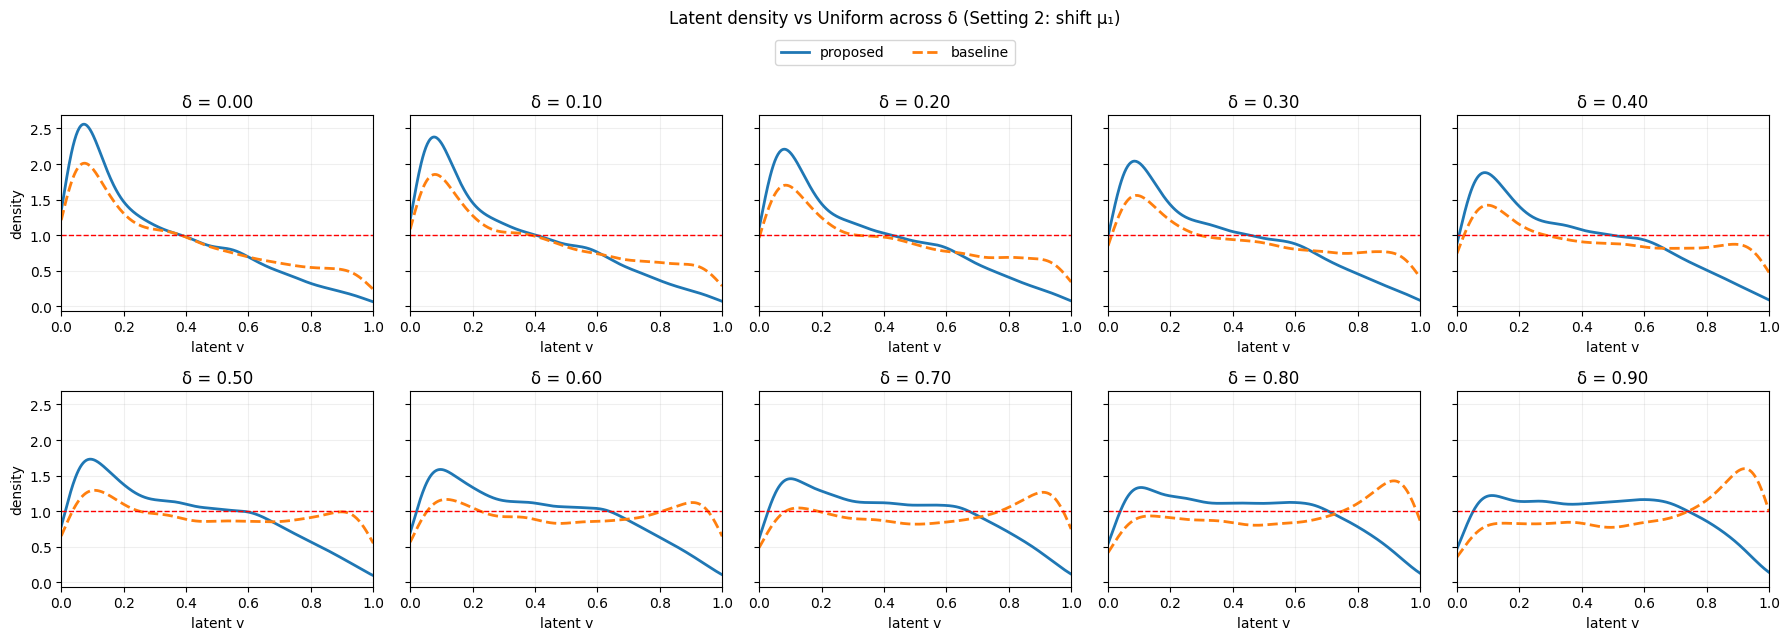

In [34]:
import sys, pathlib, numpy as np, torch, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
sys.path.insert(0, str(pathlib.Path("src").resolve()))
from data.sample_x import sample_x
from train.losses import mmd2_unif, energy_distance_unif

deltas = np.linspace(0, 1, 11)  # 10 deltas


# ------------ run sweep & plot 2x5 ------------
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
grid = np.linspace(0, 1, 400)

for ax, delta in zip(axes.ravel(), deltas):
    mu = np.array([-1, delta], dtype=float)
    X = sample_x(
        n_samples=Cfg.n_samples,
        dist_type="gaussian",
        params={"mean": mu, "cov": Cfg.dist_cov},
        seed=1,
        truncate_box=truncate_box,
    ).astype(np.float32)

    v_prop = encode_to_latent(model,     X, device)[:, 0]
    v_base = encode_to_latent(model_enc, X, device)[:, 0]

    kde_p  = gaussian_kde(v_prop)(grid)
    kde_b  = gaussian_kde(v_base)(grid)

    ax.plot(grid, kde_p, lw=2, label="proposed")
    ax.plot(grid, kde_b, lw=2, ls="--", label="baseline")
    ax.axhline(1.0, ls="--", c="red", lw=1)
    ax.set_title(f"δ = {delta:.2f}")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.2)
    if ax in axes[:,0]:
        ax.set_ylabel("density")
    ax.set_xlabel("latent v")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Latent density vs Uniform across δ (Setting 2: shift μ₁)", y=1.06)
fig.tight_layout()
plt.show()


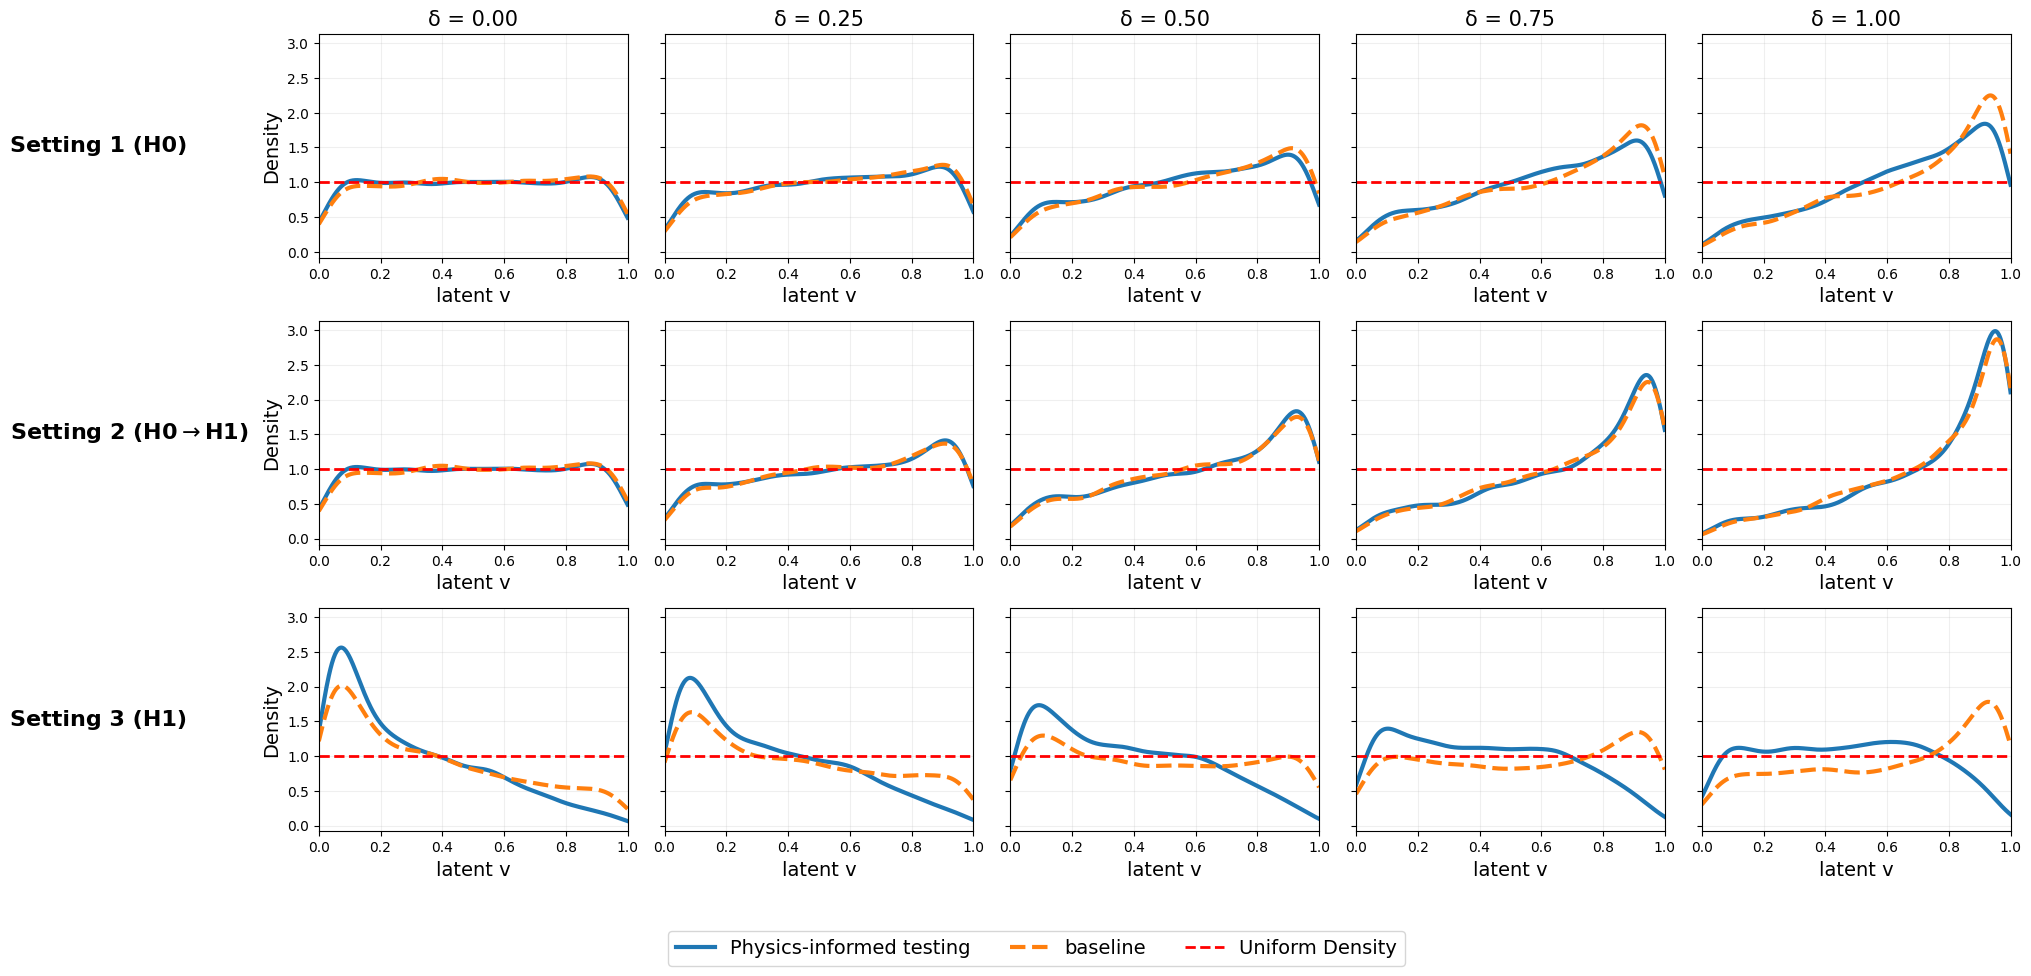

In [35]:
deltas = [0.00, 0.25, 0.50, 0.75, 1.00]

settings = [
    (r"Setting 1 (H0)",      np.array([0.0, 0.0]), np.array([0.0, 1.0])),
    (r"Setting 2 (H0$\to$H1)",  np.array([0.0, 0.0]), np.array([1.0, 0.0])),
    (r"Setting 3 (H1)",np.array([-1.0, 0.0]),np.array([0.0, 1.0])),
]

fig, axes = plt.subplots(len(settings), len(deltas), figsize=(20, 9), sharey=True)
grid = np.linspace(0, 1, 400)

for row, (title, mu_base, direction) in enumerate(settings):
    # plotting
    for ax, delta in zip(axes[row], deltas):
        mu = mu_base + delta * direction
        X = sample_x(
            n_samples=Cfg.n_samples,
            dist_type="gaussian",
            params={"mean": mu, "cov": Cfg.dist_cov},
            seed=1,
            truncate_box=truncate_box,
        ).astype(np.float32)

        v_prop = encode_to_latent(model,     X, device)[:, 0]
        v_base = encode_to_latent(model_enc, X, device)[:, 0]

        kde_p  = gaussian_kde(v_prop)(grid)
        kde_b  = gaussian_kde(v_base)(grid)

        ax.plot(grid, kde_p, lw=3, label="Physics-informed testing")
        ax.plot(grid, kde_b, lw=3, ls="--", label="baseline")
        ax.axhline(1.0, ls="--", c="red", lw=2,label='Uniform Density')
        ax.set_title(f"δ = {delta:.2f}" if row == 0 else "",fontsize=15)
        ax.set_xlim(0, 1); ax.grid(True, alpha=0.2)
        if ax is axes[row][0]:
            # 1) vertical y-label (common meaning)
            ax.set_ylabel("Density", fontsize=14, rotation=90)

            # 2) horizontal row subtitle on the left
            ax.text(
                x=-1, y=0.5, s=title,                # move x as needed
                transform=ax.transAxes,                 # axes coords: (0,0) bottom-left, (1,1) top-right
                ha="left", va="center",
                fontsize=16,fontweight="bold",
            )
        ax.set_xlabel("latent v",fontsize=14)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.03),
    fontsize=14,
)

# fig.suptitle("Latent density vs Uniform across δ (all settings)", y=1.08)
fig.tight_layout()
plt.show()

# # ------------ print metrics per δ, per setting ------------
# for title, mu_base, direction in settings:
#     print(f"\n{title}")
#     print("delta | MMD^2 prop | MMD^2 base | Energy prop | Energy base | KS prop | KS base")
#     rows = []
#     for delta in deltas:
#         mu = mu_base + delta * direction
#         X = sample_x(
#             n_samples=n_samples,
#             dist_type="gaussian",
#             params={"mean": mu, "cov": cov},
#             seed=2,  # different seed from plot
#             truncate_box=truncate_box,
#         ).astype(np.float32)
#         v_prop = encode_to_latent(model,     X, device)[:, 0]
#         v_base = encode_to_latent(model_enc, X, device)[:, 0]
#         mmd_p, ed_p, ks_p = stats_vs_unif(v_prop)
#         mmd_b, ed_b, ks_b = stats_vs_unif(v_base)
#         rows.append((delta, mmd_p, mmd_b, ed_p, ed_b, ks_p, ks_b))
#         print(f"{delta:4.2f} | {mmd_p:+.3e} | {mmd_b:+.3e} | {ed_p:+.3e} | {ed_b:+.3e} | {ks_p:.3e} | {ks_b:.3e}")


## Testing

In [1]:
import numpy as np, pandas as pd, torch
from joblib import Parallel, delayed



def ks_pvalue_to_uniform(v_np: np.ndarray) -> float:
    """
    KS test p-value for H0: v ~ Uniform(0,1).
    Assumes v is in [0,1]. If not, clip (or better: fix encoder output).
    """
    v = np.asarray(v_np, dtype=float).ravel()
    # If your latent is *supposed* to be in [0,1], clipping is reasonable for diagnostics.
    v = np.clip(v, 0.0, 1.0)
    return float(kstest(v, "uniform", args=(0.0, 1.0)).pvalue)

def ks_2sample_pvalue(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    # if your latent is supposed to be in [0,1], you can optionally clip:
    # x = np.clip(x, 0.0, 1.0); y = np.clip(y, 0.0, 1.0)
    return float(ks_2samp(x, y, alternative="two-sided", method="asymp").pvalue)



def sweep_direction_parallel_twosample_ks(
    mu_base,
    direction,
    deltas,
    *,
    n_samples=2000,
    cov=np.diag([1., 1.]),
    truncate_box=None,
    seed=1,
    n_reps=10,
    n_jobs=-1,
    backend="threading",
):
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=len(deltas) * n_reps, dtype=np.uint32)
    cov = np.asarray(cov, float)

    def one(delta, rep_seed):
        rep_seed = int(rep_seed)
        mu_shift = np.asarray(mu_base, float) + float(delta) * np.asarray(direction, float)

        # baseline sample
        X0 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": np.asarray((0,0), float), "cov": cov},
            seed=rep_seed,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # shifted sample (different seed to avoid identical draws)
        X1 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu_shift, "cov": cov},
            seed=rep_seed + 99991,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # encode both samples for both models
        v0_p = encode_to_latent(model,     X0, device)[:, 0]
        v1_p = encode_to_latent(model,     X1, device)[:, 0]
        v0_b = encode_to_latent(model_enc, X0, device)[:, 0]
        v1_b = encode_to_latent(model_enc, X1, device)[:, 0]

        # two-sample KS p-values
        p_p = ks_2sample_pvalue(v0_p, v1_p)
        p_b = ks_2sample_pvalue(v0_b, v1_b)

        return float(delta), float(mu_shift[0]), float(mu_shift[1]), p_p, p_b

    tasks = [(delta, seeds[i * n_reps + j]) for i, delta in enumerate(deltas) for j in range(n_reps)]
    results = Parallel(n_jobs=n_jobs, backend=backend)(delayed(one)(delta, s) for delta, s in tasks)

    rows = []
    for i, delta in enumerate(deltas):
        chunk = results[i * n_reps : (i + 1) * n_reps]
        p_p = np.array([r[3] for r in chunk], dtype=float)
        p_b = np.array([r[4] for r in chunk], dtype=float)
        mu1, mu2 = chunk[0][1], chunk[0][2]

        rows.append({
            "delta": float(delta),
            "mu1": float(mu1),
            "mu2": float(mu2),
            'pval': p_p,
            'pval_base': p_b,
            "ks_p_prop_mean": float(np.mean(p_p)),
            "ks_p_base_mean": float(np.mean(p_b)),
            "ks_p_prop_std":  float(np.std(p_p)),
            "ks_p_base_std":  float(np.std(p_b)),

        })

    return pd.DataFrame(rows)


In [ ]:
deltas = np.linspace(0, 1, 21)
truncate_box = (-3.0, 3.0)
n_reps = 100
n_jobs=15

df1 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)
df2 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(1,0), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)
df3 = sweep_direction_parallel_twosample_ks(mu_base=(-1,0), direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)


KeyError: 'pval'

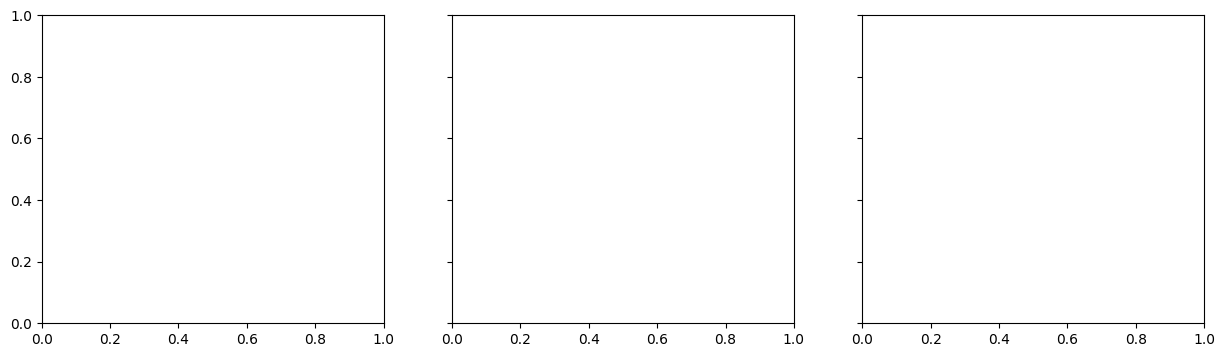

In [ ]:

def plot_power_three(df1, df2, df3, *, alpha=0.1, boundary_delta=0.5, jitter=0.015, seed=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    titles = [
        r"Setting 1 (H0)",
        r"Setting 2 (H0$\to$H1)",
        r"Setting 3 (H1)",
    ]

    rng = np.random.default_rng(seed)

    for k, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles), start=1):
        delta = df["delta"].to_numpy()

        # empirical power from p-values
        rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
        rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()

        ax.plot(delta, rej_prop, lw=3, label=r"Physics-informed testing")
        ax.plot(delta, rej_base, lw=3, ls="--", label="baseline")

        # alpha line with label (only label once to avoid duplicate legend entries)
        ax.axhline(alpha, color="k", ls=":", lw=1.5, alpha=0.8,
                   label=(r"level $\alpha$" if k == 2 else None))

        # safety boundary (only in setting 2, keep label once)
        if title.startswith("Setting 2"):
            ax.axvline(boundary_delta, color="red", ls=":", lw=2,
                       label="safety boundary")

        # oracle/idealized power curve
        if title.startswith("Setting 1"):
            oracle = np.zeros_like(delta)
        elif title.startswith("Setting 2"):
            oracle = (delta >= boundary_delta).astype(float)
        else:  # Setting 3
            oracle = np.ones_like(delta)

        # jitter so it doesn't overlap perfectly
        oracle_j = np.clip(oracle + rng.uniform(-jitter, jitter, size=oracle.shape), 0.0, 1.0)

        # plot oracle (step-ish)
        ax.plot(delta, oracle_j, lw=2.5, ls="-.", alpha=0.9,
                label=(r"oracle power (idealized)" if k == 2 else None))

        ax.set_xlabel(r"Shift magnitude $\delta$",fontsize=14)
        ax.set_title(title)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(r"Power",fontsize=14)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.12), fontsize=13)

    fig.tight_layout()
    plt.show()
 
# usage
alpha=0.1
plot_power_three(df1, df2, df3, alpha=alpha, boundary_delta=0.5)
